In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    ConfusionMatrixDisplay,
)

### Load the dataset

In [2]:
dataSet = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/fruits.csv")

RANDOM_SEED = 0

# 1. Data Analysis

In [3]:
info_df = pd.DataFrame(
    {
        "Column": dataSet.columns,
        "Null": (dataSet.notnull().sum().values - dataSet.count().values),
        "Unique": dataSet.nunique().values,
        "Dtype": dataSet.dtypes.values,
    }
)

info_df

,Column,Null,Unique,Dtype
0,Frutto,0,5,object
1,Peso (g),0,470,float64
2,Diametro medio (mm),0,487,float64
3,Lunghezza media (mm),0,373,float64
4,Durezza buccia (1-10),0,349,float64
5,Dolcezza (1-10),0,305,float64


## Dataset Structure and Data Quality

The inspection of the dataset using the `.info()` method shows that all 500 observations are complete, with no missing (*null*) values across any of the columns. This indicates that no imputation or missing-value handling is required at this stage.

All feature variables are numerical and stored as floating-point values, making them directly usable by the KNN algorithm. Since no categorical features are present among the predictors, preprocessing steps such as one-hot encoding are unnecessary.
***

In [4]:
dataSet.describe()

,Peso (g),Diametro medio (mm),Lunghezza media (mm),Durezza buccia (1-10),Dolcezza (1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,47.313440,86.573100,5.298620,7.437640,3.593220
std,26.768797,64.293403,2.641993,1.812548,1.264899
min,8.570000,7.530000,1.150000,3.070000,1.250000
25%,24.797500,50.510000,2.672500,6.152500,2.570000
50%,42.380000,70.450000,5.670000,7.340000,3.535000
75%,68.080000,88.852500,7.455000,8.615000,4.465000
max,111.210000,299.890000,11.140000,13.720000,6.950000


## Descriptive Statistics Analysis

The descriptive statistics highlight a strong mismatch in scale across the feature set, with variables such as *Diametro medio* and *Peso* spanning much wider ranges than *Lunghezza*, *Durezza*, and *Dolcezza*. This is a critical aspect for a distance-based algorithm like KNN, as features with larger magnitudes would otherwise dominate distance computations, making feature scaling mandatory.

Additionally, size-related variables exhibit higher variability, suggesting they may play a significant role in distinguishing fruit types, while texture and taste-related features provide more fine-grained information. Some extreme values, particularly in *Diametro medio* and *Durezza buccia*, suggest the presence of potential outliers or extended measurement scales, which should be taken into account during preprocessing.
***

## Correlation Matrix

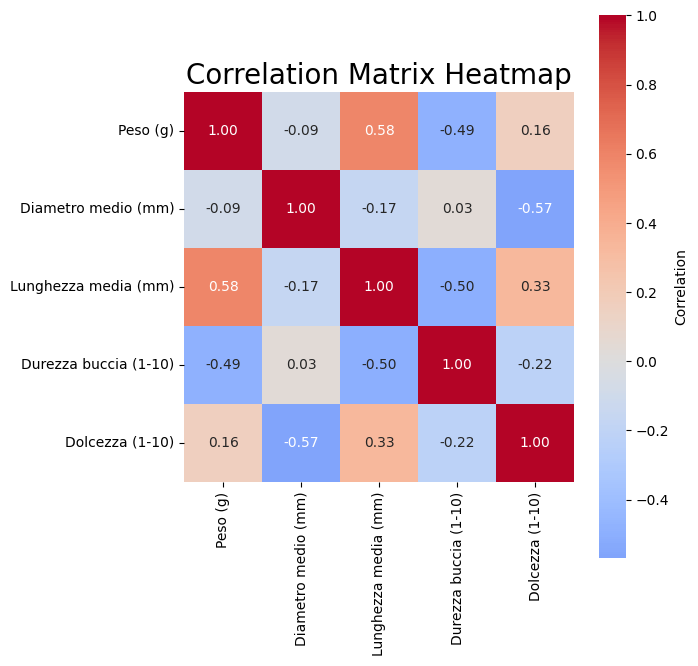

In [5]:
X = dataSet.drop(["Frutto"], axis=1)
y = dataSet["Frutto"]

correlation_matrix = X.corr()
# Create a heatmap of the correlation matrix
plt.figure(figsize=(7, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Matrix Heatmap", fontsize=20)
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation matrix shows no pairs of features with very strong linear correlation (|ρ| ≥ 0.8), indicating that multicollinearity is not a significant concern for this dataset. Some moderate correlations are present, such as between *Peso* and *Lunghezza media* (≈ 0.58) and between *Lunghezza media* and *Durezza buccia* (≈ −0.50), but these do not suggest feature redundancy. This is acceptable for a distance-based algorithm like KNN, which does not rely on parameter estimation. Nevertheless, these relationships highlight the importance of proper feature scaling to prevent certain variables from disproportionately influencing distance calculations. Overall, the feature set is suitable for proceeding with preprocessing.
***

## Splitting the dataset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

## PCA on the Training Data (for visualization)

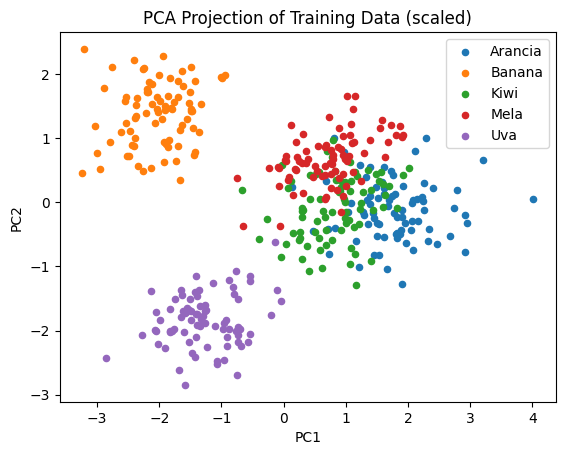

In [7]:
vis_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=2, random_state=RANDOM_SEED)),
    ]
)

X_pca = vis_pipe.fit_transform(X_train)
plt.figure()
for cls in sorted(y_train.unique()):
    mask = y_train.values == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cls, s=20)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Training Data (scaled)")
plt.legend()
plt.show()

## PCA projection analysis
To gain an intuitive understanding of the data structure, a PCA projection of the scaled training set was performed and visualized in two dimensions. Although PCA is not used for dimensionality reduction in the model, this visualization provides insight into the global structure of the data. The plot shows that some fruit classes form well-separated clusters, while others partially overlap, suggesting that most classification errors are likely to occur among similar fruit types. This observation supports the choice of a distance-based classifier and motivates the use of a moderate number of neighbors to balance local sensitivity and robustness.
***

## Exploratory Data Analysis – Summary and Next Steps

The exploratory data analysis confirmed that the dataset is complete and well-structured, with no missing values and correctly defined data types. All predictor variables are numerical and stored as floating-point values, while the target variable (*Frutto*) is categorical, making the data directly usable for a KNN-based classification task without the need for encoding.

Descriptive statistics highlighted a significant mismatch in scale across the features, with size-related variables such as *Peso* and *Diametro medio* spanning much wider ranges than texture- and taste-related attributes. This aspect is particularly relevant for a distance-based algorithm like KNN, as unscaled features with larger magnitudes would dominate distance computations.

Correlation analysis showed no pairs of features with strong linear dependence (|ρ| ≥ 0.8), indicating that multicollinearity is not a concern and that all features can be retained. Moderate correlations were observed but do not imply redundancy; instead, they further motivate careful preprocessing.

Finally, a PCA-based visualization of the scaled feature space was used as a diagnostic tool to gain an intuitive understanding of the data structure. The projection revealed that some fruit classes form well-separated clusters, while others partially overlap, suggesting that most classification errors are likely to occur among similar fruit types. This observation supports the choice of a distance-based classifier and motivates the use of a moderate number of neighbors to balance local sensitivity and robustness.

Based on these findings, the next step of the pipeline will focus on **data preprocessing**, with particular emphasis on **feature scaling**, to ensure that all variables contribute fairly to the KNN model.
***

# 2. Data Preprocessing
## Splitting
Splitting is performed above.

## Scaling
Scaling the data is handled by Pipelines.
***

# 3. Model Training

## Hyperparameter Optimization

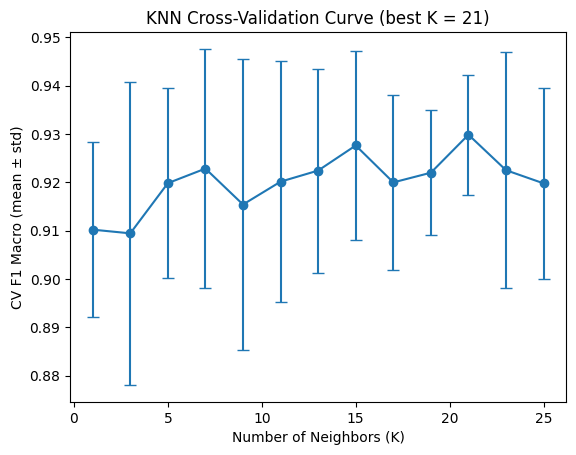

Best K: 21 | Best mean CV score: 0.9298362236794808


In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

k_values = list(range(1, 26, 2))

results = []  # (k, mean, std)

for k in k_values:
    model = Pipeline(
        [("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=k))]
    )
    try:
        scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro")
        results.append((k, scores.mean(), scores.std()))
    except Exception as e:
        print(f"Skipping k={k} due to error: {e}")

# unpack safely
ks = [r[0] for r in results]
means = [r[1] for r in results]
stds = [r[2] for r in results]

best_idx = int(np.argmax(means))
best_k = ks[best_idx]

plt.figure()
plt.errorbar(ks, means, yerr=stds, marker="o", capsize=4)
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("CV F1 Macro (mean ± std)")
plt.title(f"KNN Cross-Validation Curve (best K = {best_k})")
plt.show()

print("Best K:", best_k, "| Best mean CV score:", means[best_idx])

The cross-validation curve reports the mean and standard deviation of the macro F1-score across 5 stratified folds for different values of K.

Each point represents the average performance of a KNN model with a fixed number of neighbors, while the error bars indicate the variability across folds. The curve highlights the bias–variance tradeoff inherent in KNN, with small values of K showing higher variability and larger values leading to smoother but slightly less flexible models.

The selected value `best_k` achieves one of the highest mean scores while maintaining stable performance, making it a suitable choice for the final model.

### Cross-Validation Results
The following table shows the best five Ks determined by the Cross-Validation process.

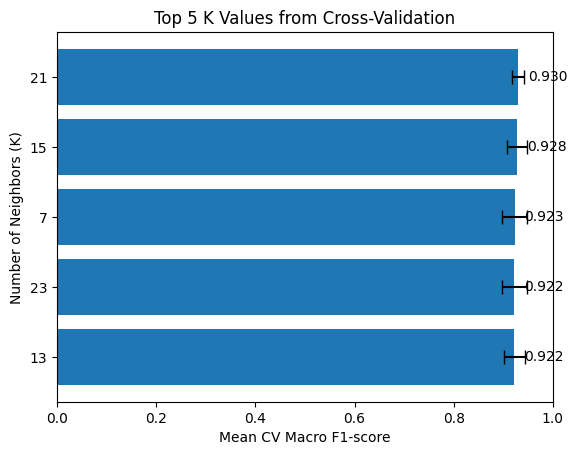

In [9]:
cv_results_df = pd.DataFrame(
    results, columns=["K", "mean_f1_macro", "std_f1_macro"]
).sort_values("mean_f1_macro", ascending=False)

cv_results_df = pd.DataFrame(
    results, columns=["K", "mean_f1_macro", "std_f1_macro"]
).sort_values(by=["mean_f1_macro", "std_f1_macro"], ascending=[False, True])

top_k_df = cv_results_df.head(5)

plt.figure()
plt.barh(
    top_k_df["K"].astype(str),
    top_k_df["mean_f1_macro"],
    xerr=top_k_df["std_f1_macro"],
    capsize=5,
)
plt.xlim(0, 1)
plt.xlabel("Mean CV Macro F1-score")
plt.ylabel("Number of Neighbors (K)")
plt.title("Top 5 K Values from Cross-Validation")
plt.gca().invert_yaxis()

# annotate values
for i, v in enumerate(top_k_df["mean_f1_macro"]):
    plt.text(v + 0.02, i, f"{v:.3f}", va="center")

plt.show()

The bar chart reports the top five values of K ranked by mean cross-validation macro F1-score, with error bars representing the standard deviation across stratified folds. This visualization highlights both predictive performance and stability, supporting the selection of a value of K that achieves high accuracy while remaining robust to different training splits.
***

## Model Selection and Training Strategy

Model selection was performed using stratified cross-validation on the training set, evaluating different values of K through the macro F1-score. The resulting cross-validation curve highlights the bias–variance tradeoff of the KNN classifier and allows the identification of a stable region with high predictive performance. Based on this analysis, `best_k` was selected as the optimal number of neighbors.

With the hyperparameter selection completed, the final KNN model can now be trained on the full training set and evaluated on the held-out test set to assess its generalization performance.

## Training the final model

In [10]:
final_model = Pipeline(
    [("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=best_k))]
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

# 5. Model Evaluation

## Metrics

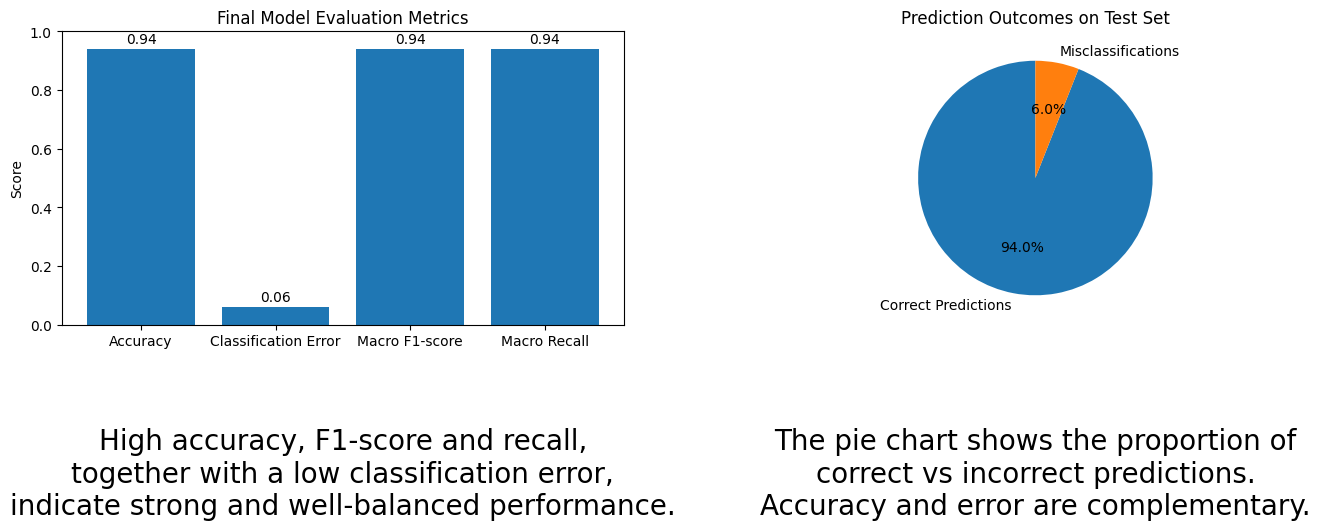

In [11]:
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
classification_error = 1 - accuracy
recall_macro = recall_score(y_test, y_pred, average="macro")


metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Classification Error",
            "Macro F1-score",
            "Macro Recall",
        ],
        "Value": [accuracy, classification_error, f1_macro, recall_macro],
    }
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- LEFT: Bar chart ----
axes[0].bar(metrics_df["Metric"], metrics_df["Value"])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score")
axes[0].set_title("Final Model Evaluation Metrics")

for i, v in enumerate(metrics_df["Value"]):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

# Text inside left subplot
axes[0].text(
    0.5,
    -0.35,
    "High accuracy, F1-score and recall,\n"
    "together with a low classification error,\n"
    "indicate strong and well-balanced performance.",
    ha="center",
    va="top",
    transform=axes[0].transAxes,
    fontsize=20,
)

# ---- RIGHT: Pie chart ----
axes[1].pie(
    [accuracy, classification_error],
    labels=["Correct Predictions", "Misclassifications"],
    autopct="%.1f%%",
    startangle=90,
)
axes[1].set_title("Prediction Outcomes on Test Set")

# Text inside right subplot
axes[1].text(
    0.5,
    -0.35,
    "The pie chart shows the proportion of\n"
    "correct vs incorrect predictions.\n"
    "Accuracy and error are complementary.",
    ha="center",
    va="top",
    transform=axes[1].transAxes,
    fontsize=20,
)

plt.tight_layout()
plt.show()

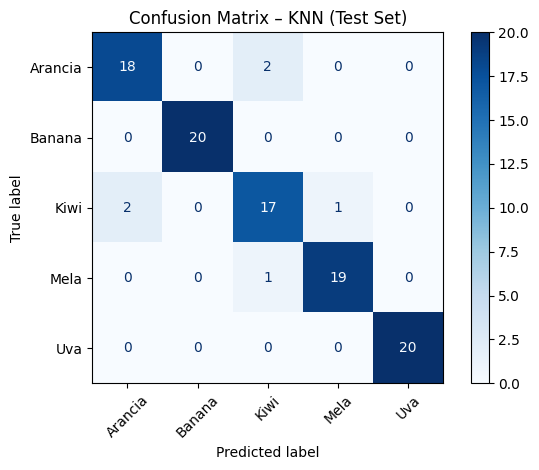

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, xticks_rotation=45, cmap="Blues"
)
plt.title("Confusion Matrix – KNN (Test Set)")
plt.tight_layout()
plt.show()

## Confusion Matrix
The confusion matrix of the final KNN model shows a strong dominance of the diagonal, indicating high classification accuracy across all fruit types. Banana and Uva are classified perfectly, which is consistent with their clear separation observed in the PCA visualization. Most misclassifications occur between Arancia, Kiwi, and Mela, reflecting partial overlap among these classes in the feature space. Importantly, errors are localized and interpretable, suggesting that the model generalizes well and that the chosen value of K effectively balances robustness and sensitivity.
***

# 6. Final Model Evaluation and Discussion

The final KNN classifier was trained using the optimal number of neighbors (`best_k`), selected through stratified cross-validation on the training set using the macro F1-score as the primary metric. This choice was motivated by the need to balance predictive performance and stability across classes.

On the held-out test set, the model achieved an accuracy of 0.94 and a macro F1-score of 0.94, indicating strong and well-balanced performance across all fruit categories. The alignment between cross-validation scores and test-set performance suggests good generalization and no evidence of overfitting. Given the balanced class distribution, the consistency between accuracy, macro F1, and weighted F1 further confirms the robustness of the model.

Class-wise analysis reveals perfect classification performance for Banana and Uva, with precision and recall equal to 1.00. This behavior is consistent with earlier exploratory and PCA-based analyses, which showed these classes to form compact and well-separated clusters in the feature space. In contrast, minor misclassifications occur among Arancia, Kiwi, and Mela, which exhibit partial overlap in the projected feature space. These localized errors are expected given the similarity of these fruit types and reflect the intrinsic ambiguity of the data rather than shortcomings of the model.

The confusion matrix further supports these conclusions, showing a strong dominance of correct predictions along the diagonal and no systematic confusion between distant classes. Errors are sparse, interpretable, and confined to semantically similar categories, reinforcing the validity of the selected model and hyperparameter configuration.

Overall, the final evaluation confirms that the proposed KNN model, combined with appropriate preprocessing and cross-validated hyperparameter selection, provides an effective and reliable solution for the fruit classification task. The results are coherent across all stages of the analysis pipeline, from exploratory data analysis to final testing, demonstrating a sound methodological approach and strong predictive performance.

***
***

## Download the model

### Set the variable below to `True` if you wish to _download_ the model:

In [13]:
import pickle


DOWNLOAD = False

if (DOWNLOAD):
    with open("knn.pickle","wb") as f:
        pickle.dump(final_model, f); 